In [ ]:
!unzip MatchedFrames.zip -d ./

In [3]:
import os
import re
from collections import Counter

img_p = r"MatchedFrames"

cnt = Counter()

for fn in os.listdir(img_p):
    if not fn.lower().endswith(".jpg"):
        continue

    m = re.search(r"_(\d+)\.jpg$", fn)
    if not m:
        continue

    v = int(m.group(1))
    if v in [1, 2, 3, 4]:
        cnt[v] = cnt[v] + 1

print("=== Counts in MatchedFrames ===")
for k in [1, 2, 3, 4]:
    print(f"ending_with_{k} : {cnt[k]}")


=== Counts in MatchedFrames ===
ending_with_1 : 196
ending_with_2 : 2872
ending_with_3 : 0
ending_with_4 : 271


In [4]:
import os
import re
import numpy as np
import tensorflow as tf

# -------------------------
# Config
# -------------------------
data_dir = r"MatchedFrames"
img_size = (96, 96)
batch_size = 64
epochs = 20
test_split = 0.10
seed = 42
classes = [1, 2, 4]

# -------------------------
# Helpers
# -------------------------
def get_label_from_name(path):
    # expects ..._<lane>.jpg at end
    fn = os.path.basename(path)
    m = re.search(r"_(\d+)\.jpg$", fn.lower())
    if m is None:
        return None
    v = int(m.group(1))
    return v if v in classes else None

def load_image_and_label(path, y):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32)
    return img, tf.cast(y, tf.float32)

def balanced_accuracy(y_true_int, y_pred_int, cls_list):
    # mean recall across classes (ignore classes with 0 support)
    ba_list = []
    for c in cls_list:
        mask = (y_true_int == c)
        denom = np.sum(mask)
        if denom == 0:
            continue
        ba_list.append(np.sum(y_pred_int[mask] == c) / denom)
    return float(np.mean(ba_list)) if len(ba_list) else 0.0

# -------------------------
# Build file list + labels
# -------------------------
paths = []
ys = []
for fn in os.listdir(data_dir):
    if not fn.lower().endswith(".jpg"):
        continue
    p = os.path.join(data_dir, fn)
    y = get_label_from_name(p)
    if y is None:
        continue
    paths.append(p)
    ys.append(y)

paths = np.array(paths)
ys = np.array(ys, dtype=np.int32)

print("Total usable images:", len(paths))
print("Label counts:", {k: int(np.sum(ys == k)) for k in classes})

# -------------------------
# Train/test split
# -------------------------
rng = np.random.default_rng(seed)
idx = np.arange(len(paths))
rng.shuffle(idx)

n_test = int(len(paths) * test_split)
test_idx = idx[:n_test]
train_idx = idx[n_test:]

train_paths, train_y = paths[train_idx], ys[train_idx]
test_paths, test_y = paths[test_idx], ys[test_idx]

print("Train:", len(train_paths), "Test:", len(test_paths))

# -------------------------
# tf.data pipelines
# -------------------------
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_y))
test_ds  = tf.data.Dataset.from_tensor_slices((test_paths, test_y))

train_ds = train_ds.map(load_image_and_label, num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = test_ds.map(load_image_and_label, num_parallel_calls=tf.data.AUTOTUNE)

# MobileNetV2 preprocessing
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.shuffle(2000, seed=seed).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


Total usable images: 3339
Label counts: {1: 196, 2: 2872, 4: 271}
Train: 3006 Test: 333


In [5]:

# -------------------------
# Model: MobileNetV2 + regression head
# -------------------------
base = tf.keras.applications.MobileNetV2(
    input_shape=(img_size[0], img_size[1], 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False  # start frozen

inp = tf.keras.Input(shape=(img_size[0], img_size[1], 3))
x = base(inp, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
out = tf.keras.layers.Dense(1, activation="linear")(x)  # regression
model = tf.keras.Model(inp, out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse"
)

model.summary()

# -------------------------
# Train
# -------------------------
hist = model.fit(train_ds, epochs=epochs, validation_data=test_ds)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 62s 694ms/step - loss: 3.2073 - val_loss: 0.6161
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - loss: 0.8546 - val_loss: 0.4169
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - loss: 0.6997 - val_loss: 0.3252
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 0.5889 - val_loss: 0.2783
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - loss: 0.5418 - val_loss: 0.2375
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 0.4616 - val_loss: 0.2309
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - loss: 0.4130 - val_loss: 0.1915
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - loss: 0.3650 - val_loss: 0.1712
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 0.3326 - val_loss: 0.1619
Epoch 10/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - loss: 0.3082 - val_loss: 0.1453
Epoch 11/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - loss: 0.2673 - val_loss: 0.1389
Epoch 12/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 115m

In [6]:
# -------------------------
# Evaluate: MAE, MSE, R2
# -------------------------
import numpy as np

y_pred = model.predict(test_ds).reshape(-1)
y_true = test_y.astype(np.float32)

mae = float(np.mean(np.abs(y_true - y_pred)))
mse = float(np.mean((y_true - y_pred) ** 2))

# R^2 = 1 - SS_res / SS_tot
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0

print("\nAfter training", epochs, "epochs:")
print("MAE :", mae)
print("MSE :", mse)
print("R2  :", r2)


6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 799ms/step

After training 20 epochs:
MAE : 0.21433745324611664
MSE : 0.09656567126512527
R2  : 0.751345157623291


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1) Save model
# -------------------------
save_root = r"model"
save_name = "Regression_Lane_Confidence_Score_RLCS"
save_dir = os.path.join(save_root, save_name)
os.makedirs(save_dir, exist_ok=True)

model.export(save_dir)  # SavedModel format folder
print("Model saved to:", save_dir)

# -------------------------
# 2) Predictions + RLCS
# -------------------------
y_pred = model.predict(test_ds).reshape(-1)
y_true = test_y.astype(np.float32)

# Regression metrics
mae = float(np.mean(np.abs(y_true - y_pred)))
mse = float(np.mean((y_true - y_pred) ** 2))
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else 0.0

print("\nAfter training", epochs, "epochs:")
print("MAE :", mae)
print("MSE :", mse)
print("R2  :", r2)

# -------------------------
# RLCS: agreement with GROUND TRUTH
# RLCS_i = exp(-(d^2)/(tau^2)), where d = |y_pred - y_true|
# -------------------------
tau = 1.0  # tolerance parameter

d = np.abs(y_pred - y_true)
rlcs = np.exp(-(d ** 2) / (tau ** 2))

print("\nRLCS summary (tau =", tau, ")")
print("Mean RLCS:", float(np.mean(rlcs)))
print("Std  RLCS:", float(np.std(rlcs)))
print("Min  RLCS:", float(np.min(rlcs)))
print("Max  RLCS:", float(np.max(rlcs)))


Saved artifact at 'model/Regression_Lane_Confidence_Score_RLCS'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138316729927248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138316729927824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138316729925712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138316729927056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138316729928016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138316729928400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138316729927440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138316729929168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138316729927632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138316729928208: TensorSpec(shape=(), dtype=tf.resource

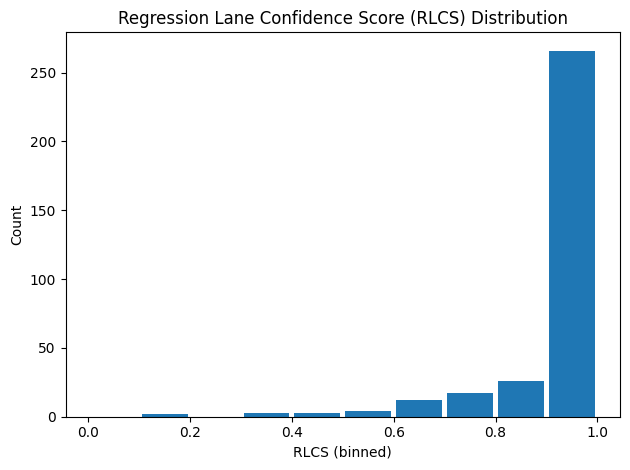

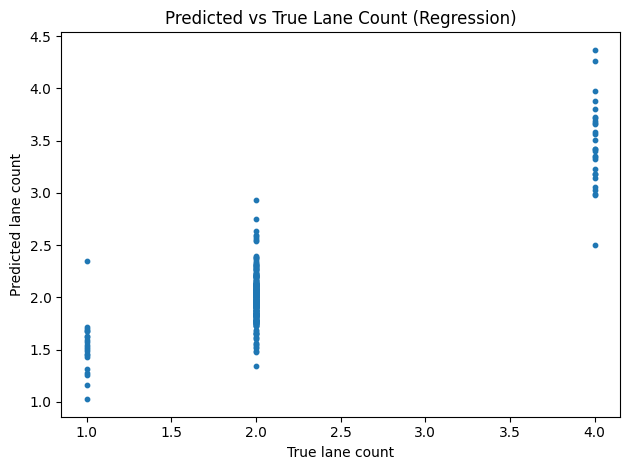

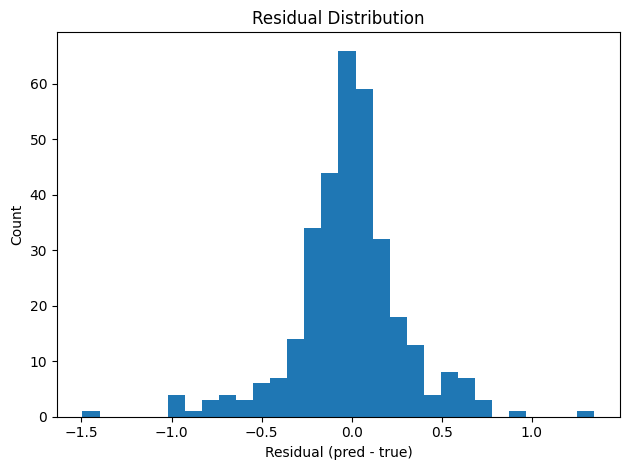

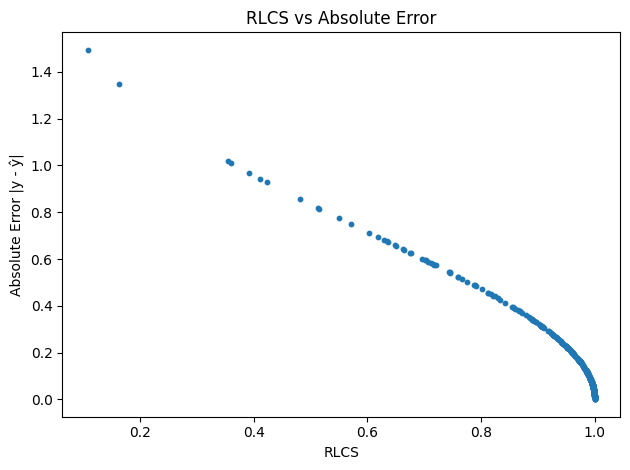

In [19]:
# -------------------------
# 3) Paper-friendly plots
# -------------------------

# (A) RLCS distribution bar chart (binned)
bins = np.linspace(0, 1.0, 11)  # 10 bins
hist, edges = np.histogram(rlcs, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

plt.figure()
plt.bar(centers, hist, width=(edges[1] - edges[0]) * 0.9)
plt.xlabel("RLCS (binned)")
plt.ylabel("Count")
plt.title("Regression Lane Confidence Score (RLCS) Distribution")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "rlcs_dist.pdf"), dpi=300, format='pdf')
plt.show()

# (B) Predicted vs True scatter (regression sanity)
plt.figure()
plt.scatter(y_true, y_pred, s=10)
plt.xlabel("True lane count")
plt.ylabel("Predicted lane count")
plt.title("Predicted vs True Lane Count (Regression)")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "pred_vs_true.pdf"), dpi=300, format='pdf')
plt.show()

# (C) Residual histogram
res = y_pred - y_true
plt.figure()
plt.hist(res, bins=30)
plt.xlabel("Residual (pred - true)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "residual_dist.pdf"), dpi=300, format='pdf')
plt.show()

# (D) RLCS vs absolute error
abs_err = np.abs(y_true - y_pred)
plt.figure()
plt.scatter(rlcs, abs_err, s=10)
plt.xlabel("RLCS")
plt.ylabel("Absolute Error |y - ŷ|")
plt.title("RLCS vs Absolute Error")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "rlcs_vs_abs_err.pdf"), dpi=300, format='pdf')
plt.show()


In [20]:
!zip -r model.zip model

  adding: model/ (stored 0%)
  adding: model/Regression_Lane_Confidence_Score_RLCS/ (stored 0%)
  adding: model/Regression_Lane_Confidence_Score_RLCS/pred_vs_true.pdf (deflated 26%)
  adding: model/Regression_Lane_Confidence_Score_RLCS/rlcs_dist.pdf (deflated 31%)
  adding: model/Regression_Lane_Confidence_Score_RLCS/fingerprint.pb (stored 0%)
  adding: model/Regression_Lane_Confidence_Score_RLCS/saved_model.pb (deflated 91%)
  adding: model/Regression_Lane_Confidence_Score_RLCS/variables/ (stored 0%)
  adding: model/Regression_Lane_Confidence_Score_RLCS/variables/variables.index (deflated 78%)
  adding: model/Regression_Lane_Confidence_Score_RLCS/variables/variables.data-00000-of-00001 (deflated 7%)
  adding: model/Regression_Lane_Confidence_Score_RLCS/assets/ (stored 0%)
  adding: model/Regression_Lane_Confidence_Score_RLCS/rlcs_vs_abs_err.pdf (deflated 23%)
  adding: model/Regression_Lane_Confidence_Score_RLCS/.keras/ (stored 0%)
  adding: model/Regression_Lane_Confidence_Score_RLCS

In [ ]:
!zip -r